# Inter-rater reliability Script


Takes in a folder of csv files from ELAN, with file names {video_name}_ {initials}. Standardizes behavior names to "allogrooming", "allolicking", and "self licking". Outputs corrleational matrix between each person (for all videos together) and ICC score.

**folder of csv data must be in same directory as this jupyter notebook, change folder path if needed**

In [7]:
#Import necessary libraries
#you may need to install some of these packages if you haven't already
import pandas as pd
import numpy as np
import pingouin as pg
from sklearn.metrics import cohen_kappa_score
import os
import re
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
# assuming all data is in same folder as this file, with folder name 'csv'
folder_path = r"/Volumes/Lab/Reliability/socialTransferBehaviors/data/20260408_allBeh/csv"
#Input initials of the user to compare all other scores against
initial_1 = "NK" 

In [82]:
#Create function to standardize behavior names
def standardize(x):
    '''
    Standardize behavior labels to canonical names.
    Removes spaces/punctuation and maps common variants/synonyms.
    '''
    label = str(x).strip().lower()
    label_cleaned = re.sub(r'[^a-zA-Z]', '', label)
    
    canonical_map = {
        # self-licking variants
        'selflicking': 'selflicking',
        'selflick': 'selflicking',
        'selflicks': 'selflicking',

        # self-grooming variants
        'selfgrooming': 'selfgrooming',
        'selfgroom': 'selfgrooming',
        'selfgrooms': 'selfgrooming',
        'autogrooming': 'selfgrooming',
        'autogroom': 'selfgrooming',

        # social grooming variants
        'allogrooming': 'allogrooming',
        'allogroom': 'allogrooming',
        'socialgrooming': 'allogrooming',

        # social licking variants
        'allolicking': 'allolicking',
        'allolick': 'allolicking',
        'sociallicking': 'allolicking',

        # huddling variants
        'huddling': 'huddling',
        'huddle': 'huddling',
    }
    
    if label_cleaned in canonical_map:
        return canonical_map[label_cleaned]
    
    # Fallback rules for unseen variants
    if label_cleaned.startswith('self') and 'groom' in label_cleaned:
        return 'selfgrooming'
    if label_cleaned.startswith('self') and 'lick' in label_cleaned:
        return 'selflicking'
    if 'groom' in label_cleaned and not label_cleaned.startswith('self'):
        return 'allogrooming'
    if 'lick' in label_cleaned and not label_cleaned.startswith('self'):
        return 'allolicking'
    
    # Keep unknown labels in cleaned form so they can still be inspected
    return label_cleaned

In [74]:
# Convert any UTF-16 CSV files in folder_path to UTF-8 (in place).
# Run this once before the ICC processing cell.
import time

converted_files = []
skipped_files = []
failed_files = []

for filename in os.listdir(folder_path):
    if not filename.lower().endswith('.csv'):
        continue

    file_path = os.path.join(folder_path, filename)
    temp_path = f"{file_path}.utf8.tmp"

    try:
        # Detect UTF-16 files using BOM bytes.
        with open(file_path, 'rb') as f:
            bom = f.read(2)

        if bom not in (b'\xff\xfe', b'\xfe\xff'):
            skipped_files.append(filename)
            continue

        for attempt in range(3):
            try:
                with open(file_path, 'r', encoding='utf-16', newline='') as f:
                    content = f.read()

                with open(temp_path, 'w', encoding='utf-8', newline='') as f:
                    f.write(content)

                os.replace(temp_path, file_path)
                converted_files.append(filename)
                break
            except BlockingIOError:
                # OneDrive/network paths can be briefly locked during writes.
                if attempt == 2:
                    raise
                time.sleep(0.3 * (attempt + 1))

    except Exception as e:
        if os.path.exists(temp_path):
            os.remove(temp_path)
        failed_files.append((filename, str(e)))

print(f"Converted {len(converted_files)} file(s) from UTF-16 to UTF-8.")
if converted_files:
    for name in sorted(converted_files):
        print(f"  converted: {name}")

print(f"Skipped {len(skipped_files)} file(s) already UTF-8 or non-UTF-16.")

if failed_files:
    print(f"Failed on {len(failed_files)} file(s):")
    for name, err in failed_files:
        print(f"  failed: {name} -> {err}")

Converted 0 file(s) from UTF-16 to UTF-8.
Skipped 84 file(s) already UTF-8 or non-UTF-16.


In [83]:
#Create data frames from each csv and initiate pairwise ICC comparisons

# dictionary to hold all the data that will be turned into final df
all_video_data = {}
large_df = pd.DataFrame()
all_initials = set()

# loop through each file 
for filename in os.listdir(folder_path):
    
    if filename.endswith('.csv'):  # Check if the file is a CSV
        file_path = os.path.join(folder_path, filename)
        
        # temp dictionary that'll be added to all_video_data at the end of the loop
        curr_vid_data = {}
        
        # extract initials and file name for labeling purposes
        # Split filename by underscore and take the last part (before .csv) as initials
        filename_parts = filename.replace('.csv', '').split('_')
        initials = filename_parts[-1]  # This will handle both 2 and 3 letter initials
        video_name = '_'.join(filename_parts[:-1])  # Everything except the last part is the video name

        all_initials.add(initials)

    
   
        # turn current csv file into a data frame
        df = pd.read_csv(file_path, header = None)
        
        # standardize the labeling to all lowercase and no spaces/punctuation
        df[0] = df[0].apply(standardize)
        
        # get the total duration of each behavior
        # 0 = behavior name
        # 1 = NaN column
        # 2 = start time
        # 3 = end time
        # 4 = duration
        # 5 = NaN column
        
        d = dict(df.groupby(0).sum()[4])
        
        # rename the keys using initial and behavior name ex) allogrooming_KT
        for key, value in d.items():
            curr_vid_data[f'{key}_{initials}'] = value
        
        
        # first time this video appears,  not yet in large dict (creates new row for the video)
        if video_name not in all_video_data:
            all_video_data[video_name] = curr_vid_data  
            
        # video already in the dictonary, just append the data to existing row
        else:
            all_video_data[video_name].update(curr_vid_data)      
        

# Create a dataframe per behavior with column = initials, rows = video and values = total duration of behavior
reliability_df = pd.DataFrame(all_video_data).T.sort_index().fillna(0)

# Create all pairwise comparisons of unique values in a list
initials_list = list(all_initials)
pairwise_comparisons = [(g1, g2) for i, g1 in enumerate(initials_list) for g2 in initials_list[i+1:]]
output = {}
behaviors = ['allogrooming', 'allolicking', 'selflicking', 'selfgrooming']
#behaviors = ['huddling']

for behavior in behaviors:
#     print(f'{behavior}')
    col = [i for i in reliability_df.columns if behavior in i]
    behavior_df = reliability_df[col]
    behavior_df.columns = behavior_df.columns.str.split('_').str[-1]  # Extract initials from column names
#     raters = df_wide.columns
    
    icc_results = {}
    
    for rater in behavior_df.columns:
        if rater != initial_1:
            temp_df = behavior_df[[initial_1, rater]].reset_index()  # Ensure video names are included
            temp_df = temp_df.melt(id_vars="index", var_name="Rater", value_name="Score")

            icc_result = pg.intraclass_corr(data=temp_df, targets='index', raters='Rater', ratings='Score')
            icc_value = icc_result[icc_result['Type'] == 'ICC2']['ICC'].values[0]
            icc_results[rater] = icc_value  # Store the ICC value
    
    output[behavior] = icc_results

    # Convert to DataFrame
    icc_df = pd.DataFrame.from_dict(icc_results, orient='index', columns=[f'ICC with {initial_1} for {behavior}']).reset_index()

    # Print ICC values
    print(icc_df)

/var/folders/f5/0p7jn0j966v5140s43jf7gdh0000gp/T/ipykernel_63495/1876142280.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  reliability_df = pd.DataFrame(all_video_data).T.sort_index().fillna(0)


   index  ICC with NK for allogrooming
0    PRB                      0.977477
1     VW                      0.945981
2    LAB                      0.957619
3    SMA                      0.743337
4     JZ                      0.982224
5     gs                      0.996984
6     IM                      0.979427
7     MN                      0.994851
8    BTN                      0.995148
9     IA                      0.304037
10   AVN                      0.997543
11  KLT2                      0.920708
12   JL2                      0.962269
   index  ICC with NK for allolicking
0    PRB                     0.994805
1     VW                     0.997572
2    LAB                     0.996325
3    SMA                     0.386611
4     JZ                     0.999619
5     gs                     0.996508
6     IM                     0.997601
7     MN                     0.996676
8    BTN                     0.999156
9     IA                     0.784256
10   AVN                     0.99790

Available lab members (initials):
1. AVN
2. BTN
3. IA
4. IM
5. JL2
6. JZ
7. KLT
8. KLT2
9. LAB
10. MN
11. NK
12. PRB
13. SMA
14. VW
15. gs

Reference initial (comparison baseline): NK
Plotting ICC scores for: AVN, BTN, IA, IM, JL2, JZ, KLT, KLT2, LAB, MN, NK, PRB, SMA, VW, gs
Saved CSV to: /Volumes/Lab/Reliability/socialTransferBehaviors/data/20260408_allBeh/csv/ICC_score_comparison_NK.csv

ICC Score Comparison against NK
Saved PNG to: /Volumes/Lab/Reliability/socialTransferBehaviors/data/20260408_allBeh/csv/ICC_score_comparison_NK.png


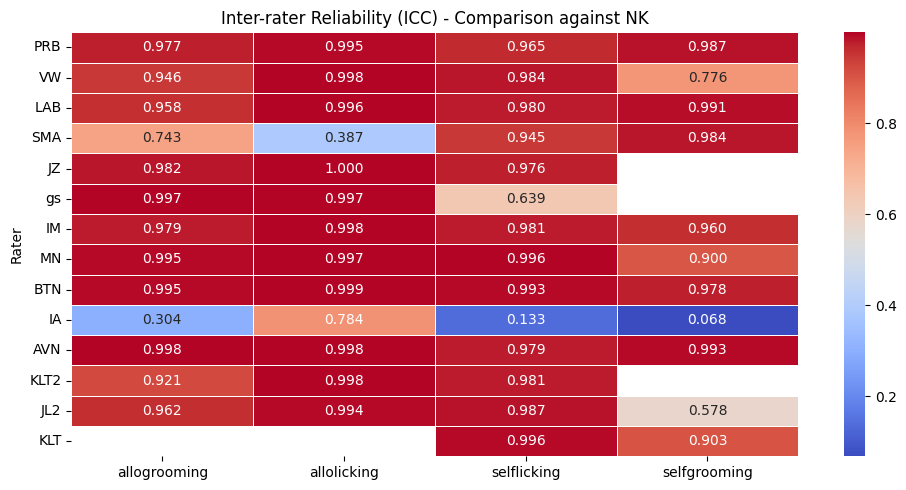

In [84]:
#Plot ICC result heat map with user-selected active lab members and save PNG/CSV

# Display all available initials
print("Available lab members (initials):")
all_available_initials = set()
for behavior_data in output.values():
    all_available_initials.update(behavior_data.keys())
all_available_initials.add(initial_1)  # Add the reference initial
sorted_initials = sorted(list(all_available_initials))

for i, initial in enumerate(sorted_initials, 1):
    print(f"{i}. {initial}")

print(f"\nReference initial (comparison baseline): {initial_1}")

# EDIT THIS LIST: Add the initials of active lab members you want to include in the plot
# Leave empty list [] to include all available initials
selected_initials = []  # Edit this list as needed

# Validate that all selected initials exist in the data
if selected_initials:
    invalid_initials = [initial for initial in selected_initials if initial not in sorted_initials]
    if invalid_initials:
        print(f"Warning: The following initials were not found in the data: {invalid_initials}")
        selected_initials = [initial for initial in selected_initials if initial in sorted_initials]
else:
    # If empty list, use all available initials
    selected_initials = sorted_initials

print(f"Plotting ICC scores for: {', '.join(selected_initials)}")

# Filter the output data to include only selected initials
filtered_output = {}
for behavior, rater_data in output.items():
    filtered_output[behavior] = {rater: icc for rater, icc in rater_data.items() 
                               if rater in selected_initials}

# Create DataFrame for plot and CSV (raters as rows, behaviors as columns)
r = pd.DataFrame(filtered_output)

# Save locations and quality
save_path_png = os.path.join(folder_path, f"ICC_score_comparison_{initial_1}.png")
save_path_csv = os.path.join(folder_path, f"ICC_score_comparison_{initial_1}.csv")
save_dpi = 300

# Save CSV summary
if not r.empty:
    r.index.name = 'Rater'
    r.to_csv(save_path_csv)
    print(f"Saved CSV to: {save_path_csv}")

# Only plot if there's data to show
if not r.empty:
    print(f"\nICC Score Comparison against {initial_1}")
    plt.figure(figsize=(10, 5))
    sns.heatmap(r, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".3f")
    plt.yticks(rotation=0)
    plt.title(f'Inter-rater Reliability (ICC) - Comparison against {initial_1}')
    plt.tight_layout()
    plt.savefig(save_path_png, dpi=save_dpi, bbox_inches='tight')
    print(f"Saved PNG to: {save_path_png}")
    plt.show()
else:
    print("No data available for the selected lab members.")

In [36]:
# Diagnostic: find non-numeric values that break ICC
problem_rows = []
for col in reliability_df.columns:
    s = reliability_df[col]
    numeric = pd.to_numeric(s, errors='coerce')
    bad_mask = numeric.isna() & s.notna()
    if bad_mask.any():
        for video_name, raw_value in s[bad_mask].items():
            problem_rows.append((video_name, col, raw_value))

print(f"Found {len(problem_rows)} non-numeric behavior duration value(s).")
for video_name, col, raw_value in problem_rows[:50]:
    print(f"video={video_name} | column={col} | value={str(raw_value)[:120]}")

if len(problem_rows) > 50:
    print(f"... and {len(problem_rows)-50} more")

Found 0 non-numeric behavior duration value(s).
